# ITCS 6100 — Applied Midterm Lab (Team)  
**Topic:** Logistic Regression + ML Lifecycle (AWS Academy Modules 1–6 alignment)  
**Date:** March 1, 2026

## Team Information (REQUIRED)
- **Team Name:**  Project Group 7
- **Student Names:**  
  -  Lauren Sharpe
  -  Krishna Sasank Ravi
  -  Chandra Kiran Suraparaju
  -  Sumaita Rahman
  

## Deliverables (What you submit)
1. This completed notebook (`.ipynb`)
2. Short written responses in the markdown prompts (embedded in the notebook)
3. One submission per team in Canvas
4. Individual submission by each team member to the Github class

## Rules
- You may use course notes and AWS Academy module materials.
- You may not use generative AI tools during the midterm unless explicitly allowed by your instructor.
- Your analysis must be your team’s own work.

## Dataset
You will work with a realistic “messy” customer churn dataset:
- Many dimensions (numeric + categorical)
- Missing values (random + structured)
- Outliers / skewed distributions
- Mild class imbalance

**Target:** `churn` (1 = churned, 0 = stayed)

---

# ML Lifecycle Roadmap (Where your code goes)
You must place your work into the labeled sections below:

1. **INGEST** (load + inspect data)
2. **CLEAN** (handle missing values, outliers, data issues)
3. **PREPARE** (split, encode, scale, pipeline)
4. **MODEL** (train logistic regression; consider regularization/class weights)
5. **ANALYZE** (confusion matrix, metrics, threshold tuning, interpretation)

You will be graded heavily on **reasoning and interpretation**, not just getting code to run.


In [ ]:
# =========================
# DATASET GENERATOR (RUN ONLY TO GENERATE THE DATASET FOR OUR EXAM, DO NOT EDIT)
# =========================
# If 'synthetic_churn.csv' is not present, this cell will generate it.
# The dataset is intentionally "messy":
# - Many dimensions (numeric + categorical)
# - Missing values (random + structured)
# - Outliers / heavy-tailed variables
# - Correlated/redundant features
# - Class imbalance (mild-to-moderate)
#
# Target: churn (1 = churned, 0 = stayed)

import numpy as np
import pandas as pd

from pathlib import Path

rng = np.random.default_rng(6100)
out_path = Path("synthetic_churn.csv")

if not out_path.exists():
    n = 6000

    # Core demographics / account
    age = rng.integers(18, 80, size=n)
    tenure_months = rng.integers(0, 120, size=n)
    income = rng.lognormal(mean=10.6, sigma=0.45, size=n)  # heavy-tailed
    household_size = rng.integers(1, 7, size=n)

    # Usage / behavior
    logins_30d = rng.poisson(lam=12, size=n)
    support_tickets_90d = rng.poisson(lam=1.2, size=n)
    avg_session_mins = rng.gamma(shape=2.3, scale=8.0, size=n)  # right-skew
    days_since_last_login = rng.integers(0, 60, size=n)

    # Payments / billing
    monthly_fee = rng.normal(loc=65, scale=18, size=n).clip(10, 180)
    late_payments_12m = rng.poisson(lam=0.8, size=n)
    autopay = rng.choice(["Yes", "No"], p=[0.62, 0.38], size=n)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], p=[0.56, 0.24, 0.20], size=n)

    # Product / plan
    plan = rng.choice(["Basic", "Plus", "Pro"], p=[0.50, 0.35, 0.15], size=n)
    add_ons = rng.integers(0, 6, size=n)
    streaming = rng.choice(["None", "Music", "Video", "Both"], p=[0.18, 0.24, 0.28, 0.30], size=n)

    # Geography + channel
    region = rng.choice(["Northeast", "South", "Midwest", "West"], p=[0.19, 0.33, 0.22, 0.26], size=n)
    signup_channel = rng.choice(["Web", "Retail", "Partner", "Phone"], p=[0.52, 0.20, 0.18, 0.10], size=n)

    # Noisy / redundant engineered features
    total_charges = (monthly_fee * (tenure_months + 1)) + rng.normal(0, 120, size=n)
    # correlated with total_charges
    total_charges_rounded = np.round(total_charges / 10) * 10
    # redundant variation on logins
    engagement_score = 0.55*np.tanh(logins_30d/20) + 0.30*np.tanh(avg_session_mins/30) - 0.25*np.tanh(days_since_last_login/30) + rng.normal(0, 0.06, size=n)

    # Introduce outliers: a small fraction of extreme monthly fees and income
    outlier_idx = rng.choice(np.arange(n), size=int(0.01*n), replace=False)
    monthly_fee[outlier_idx] *= rng.uniform(2.0, 3.5, size=len(outlier_idx))
    income[outlier_idx] *= rng.uniform(3.0, 8.0, size=len(outlier_idx))

    # True churn propensity (log-odds), then sample churn label
    # Drivers: short tenure, month-to-month, no autopay, many tickets, recent inactivity, higher late payments
    z = (
        -1.2
        + 0.015*(days_since_last_login)
        + 0.22*(support_tickets_90d)
        + 0.18*(late_payments_12m)
        - 0.012*(tenure_months)
        + 0.35*(contract == "Month-to-month").astype(int)
        - 0.30*(contract == "Two year").astype(int)
        + 0.22*(autopay == "No").astype(int)
        + 0.20*(plan == "Basic").astype(int)
        - 0.10*(plan == "Pro").astype(int)
        + 0.15*(streaming == "None").astype(int)
        - 0.08*(streaming == "Both").astype(int)
        + rng.normal(0, 0.35, size=n)
    )

    p = 1 / (1 + np.exp(-z))
    churn = rng.binomial(1, p, size=n)

    df = pd.DataFrame({
        "age": age,
        "tenure_months": tenure_months,
        "income": income,
        "household_size": household_size,
        "logins_30d": logins_30d,
        "support_tickets_90d": support_tickets_90d,
        "avg_session_mins": avg_session_mins,
        "days_since_last_login": days_since_last_login,
        "monthly_fee": monthly_fee,
        "late_payments_12m": late_payments_12m,
        "autopay": autopay,
        "contract": contract,
        "plan": plan,
        "add_ons": add_ons,
        "streaming": streaming,
        "region": region,
        "signup_channel": signup_channel,
        "total_charges": total_charges,
        "total_charges_rounded": total_charges_rounded,
        "engagement_score": engagement_score,
        "churn": churn
    })

    # Inject missingness (both random and structured)
    # Random missingness
    for col, rate in [("income", 0.06), ("avg_session_mins", 0.05), ("monthly_fee", 0.03), ("region", 0.02), ("streaming", 0.03)]:
        mask = rng.random(n) < rate
        df.loc[mask, col] = np.nan

    # Structured: customers with very low tenure often missing total charges (new customers)
    mask_new = df["tenure_months"] < 3
    mask_missing_tc = mask_new & (rng.random(n) < 0.55)
    df.loc[mask_missing_tc, "total_charges"] = np.nan
    df.loc[mask_missing_tc, "total_charges_rounded"] = np.nan

    # Slight label noise (realistic)
    flip = rng.random(n) < 0.015
    df.loc[flip, "churn"] = 1 - df.loc[flip, "churn"]

    df.to_csv(out_path, index=False)
    print(f"✅ Generated dataset: {out_path.resolve()} with shape {df.shape}")
else:
    print(f"ℹ️ Found existing dataset: {out_path.resolve()}")


✅ Generated dataset: /content/synthetic_churn.csv with shape (6000, 21)


## 1) INGEST — Load and Inspect

**Tasks**
1. Load `synthetic_churn.csv` into a DataFrame.
2. Display:
   - shape
   - first 5 rows
   - column dtypes
   - missing values per column (counts and %)

**Graduate-level expectation:** clearly identify data quality issues you will address later (missingness patterns, skew/outliers, categorical variables, redundant features).


In [ ]:
# TODO (INGEST)
import pandas as pd

# 1) Load
df = pd.read_csv('synthetic_churn.csv')

# 2) Inspect
print("--- Shape ---")
display(df.shape)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Column Data Types ---")
display(df.dtypes)

# 3) Missingness summary (counts + percent)
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'count': missing_counts,
    'percentage': missing_percent
}).sort_values(by='count', ascending=False)

print("\n--- Missingness Summary ---")
display(missing_summary)

--- Shape ---


(6000, 21)


--- First 5 Rows ---


,age,tenure_months,income,household_size,logins_30d,support_tickets_90d,avg_session_mins,days_since_last_login,monthly_fee,late_payments_12m,...,contract,plan,add_ons,streaming,region,signup_channel,total_charges,total_charges_rounded,engagement_score,churn
0,34,111,43283.836559,3,6,1,8.015632,37,75.741544,1,...,Month-to-month,Pro,3,Both,Midwest,Web,8393.730283,8390.0,0.090024,0
1,23,74,45608.528368,6,14,2,10.078930,44,100.957688,1,...,One year,Basic,1,Both,South,Web,7654.510301,7650.0,0.193464,1
2,69,113,31254.972376,2,9,0,23.226331,37,30.898616,1,...,One year,Pro,2,Both,South,Web,3662.195331,3660.0,0.178748,0
3,65,97,28989.989283,6,22,1,16.334476,14,105.354848,1,...,One year,Basic,3,Both,South,Phone,10144.071051,10140.0,0.479665,0
4,46,43,107671.977983,2,14,3,5.636188,6,99.973303,1,...,Month-to-month,Plus,0,Video,Northeast,Phone,4372.902650,4370.0,0.404659,0



--- Column Data Types ---


,0
age,int64
tenure_months,int64
income,float64
household_size,int64
logins_30d,int64
support_tickets_90d,int64
avg_session_mins,float64
days_since_last_login,int64
monthly_fee,float64
late_payments_12m,int64



--- Missingness Summary ---


,count,percentage
streaming,1251,20.850000
income,350,5.833333
avg_session_mins,338,5.633333
monthly_fee,195,3.250000
region,113,1.883333
total_charges,90,1.500000
total_charges_rounded,90,1.500000
tenure_months,0,0.000000
age,0,0.000000
logins_30d,0,0.000000


### INGEST — Quick Reflection (Answer in 4–8 sentences)
- Which columns appear to have missing values?

From what I can see in the dataset, the columns that have missing values are income, avg_session_mins, monthly_fee, streaming, region, total_charges, and total_charges_rounded. I’m saying this because when checking the summary of the data these columns show fewer non-null entries than the total number of rows.  
- Which columns look categorical vs numeric?

 The columns that look categorical are autopay, contract, plan, streaming, region, and signup_channel because they contain text values that represent groups or labels instead of numbers. For example, contract might have values like month-to-month or annual, and plan could have different plan names. These don’t represent quantities, just categories.
- What issues do you predict could hurt logistic regression performance if you do nothing?

If we do nothing, the first big issue is missing values, because logistic regression can’t handle NaNs directly, so the model might either fail to run or drop a lot of rows automatically. That would reduce the amount of data and possibly bias the results.

## 2) CLEAN — Missing Values, Outliers, Data Issues

**Tasks**
1. Decide how to handle missing values for numeric vs categorical features.
2. Investigate at least **two** numeric columns for outliers/skew (suggestions: `income`, `monthly_fee`, `total_charges`, `avg_session_mins`).
3. Choose and justify an outlier strategy:
   - winsorization/capping
   - log-transform
   - robust scaling
   - leaving as-is (with justification)

**Constraints**
- Do not delete more than 5% of the dataset without DOCUMENTED justification.
- Your approach must be repeatable (i.e., implementable in code and applied consistently).

**Deliverable:** A short markdown justification of your decisions.


In [ ]:
# TODO (CLEAN)

import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("synthetic_churn.csv")

# -------------------------------
# A) HANDLE MISSING VALUES
# -------------------------------

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# 1. Numeric → median imputation (robust to outliers)
for col in numeric_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 2. Categorical → fill with "Missing"
for col in categorical_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna("Missing")


# -------------------------------
# B) EXPLORE DISTRIBUTIONS / OUTLIERS
# (Investigate at least two columns)
# -------------------------------

cols_to_check = ['income', 'total_charges']

for col in cols_to_check:
    print(f"\nSummary for {col}")
    print(df[col].describe())
    print("Quantiles:")
    print(df[col].quantile([0.01, 0.05, 0.95, 0.99]))


# -------------------------------
# C) OUTLIER / SKEW STRATEGY
# -------------------------------

# Strategy:
# - income: likely right-skewed → apply log transform
# - total_charges: cap extreme outliers using 1st & 99th percentile

# 1. Log transform income (create new column, do NOT overwrite original)
df['income_log'] = np.log1p(df['income'])

# 2. Winsorization (capping) for total_charges
lower_cap = df['total_charges'].quantile(0.01)
upper_cap = df['total_charges'].quantile(0.99)

df['total_charges_capped'] = df['total_charges'].clip(lower=lower_cap, upper=upper_cap)


# -------------------------------
# D) OPTIONAL: ROBUST SCALING (repeatable)
# -------------------------------

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

cols_to_scale = ['income_log', 'total_charges_capped', 'monthly_fee', 'avg_session_mins']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


print("\nCleaning complete. Shape of dataset:", df.shape)



Summary for income
count      6000.000000
mean      45778.786802
std       28804.410361
min        8514.268643
25%       30349.605028
50%       40315.824101
75%       53621.750680
max      598843.254961
Name: income, dtype: float64
Quantiles:
0.01     14332.674016
0.05     19508.957862
0.95     85356.103072
0.99    135838.851515
Name: income, dtype: float64

Summary for total_charges
count     6000.000000
mean      3990.487861
std       2532.032894
min       -175.409628
25%       1923.407123
50%       3689.181424
75%       5742.417256
max      12971.691710
Name: total_charges, dtype: float64
Quantiles:
0.01      104.080382
0.05      461.070281
0.95     8679.017874
0.99    10367.310868
Name: total_charges, dtype: float64

Cleaning complete. Shape of dataset: (6000, 23)


### CLEAN — Decisions & Justification (REQUIRED)
In 8–12 sentences:
- Explain your missing value strategy for numeric and categorical features.

For missing numeric values, I decided to use median imputation instead of the mean. I chose the median because some columns like income and total_charges seem right-skewed, so the mean could be influenced by extreme values. The median is more robust and gives a better “typical” value when outliers are present. This way, I can fill in missing values without distorting the distribution too much. I also avoided dropping rows because that could remove a large portion of the dataset, especially since some columns like streaming had many missing values.

For categorical features, I filled missing values with a new category called "Missing". I did this instead of using the most frequent category because missingness itself might carry useful information. For example, if streaming is missing, it might mean the customer does not have that feature or it was not recorded properly. By creating a separate category, the model can learn whether missingness has predictive value. This approach is also consistent and repeatable in code, so it can be applied the same way to training and future data. Overall, the strategy keeps all rows and handles missing data in a way that reduces bias and preserves information.


- Identify which variables had outliers/skew and what you did about them.

From exploring the distributions, income and total_charges clearly showed right skew. The upper percentiles (like the 95th and 99th) were much higher than the median, which suggests some extreme high values pulling the distribution to the right. monthly_fee and avg_session_mins had some spread, but they were not as heavily skewed as income.

For income, I applied a log transformation using log1p() and created a new column instead of overwriting the original. This helps reduce the impact of extreme high values and makes the distribution more symmetric, which is better for logistic regression. For total_charges, I used winsorization by capping values at the 1st and 99th percentiles. This keeps all observations but limits the influence of extreme outliers. I chose these strategies because they are repeatable in code and do not require deleting rows from the dataset.

- Explain the tradeoff of your choice (what you might lose vs gain).

The main benefit of my approach is that it reduces the influence of extreme values without deleting data. By using a log transform on income, I make the distribution more normal-like, which can help logistic regression learn more stable and meaningful coefficients. By capping total_charges at the 1st and 99th percentiles, I prevent extreme outliers from dominating the model. This can improve model stability and reduce variance.

However, the tradeoff is that I might lose some information about truly extreme customers. For example, very high-income customers could actually behave differently, and transforming or capping their values reduces that distinction. Winsorization also slightly distorts the real distribution because the most extreme values are no longer their true amounts. Log transformation can also make interpretation less intuitive since coefficients now relate to the log of income instead of raw income. So basically, I gain stability and better model performance, but I lose some precision and interpretability at the extreme ends.

## 3) PREPARE — Split, Encode, Scale

**Tasks**
1. Create `X` (features) and `y` (target).
2. Train/test split (use stratification).
3. Encode categorical variables (one-hot encoding).
4. Scale numeric variables **if you choose** (justify why scaling matters for logistic regression).
5. Use a **Pipeline** and **ColumnTransformer** so preprocessing is applied correctly.

**Deliverable:** Your final preprocessing pipeline.


In [ ]:
# TODO (PREPARE)
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

RANDOM_STATE = 42

# 1) X, y
y = df["churn"]
X = df.drop(columns=["churn"])

# 2) Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

# 3) Split (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean(), " Test churn rate:", y_test.mean())

class Winsorizer(BaseEstimator, TransformerMixin):
    '''
    Clip numeric columns to percentile bounds learned from training data.
    Works with numpy arrays (after imputation) inside a Pipeline.
    '''
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_ = np.nanquantile(X, self.lower_q, axis=0)
        self.upper_ = np.nanquantile(X, self.upper_q, axis=0)
        # Guard: if a feature is constant / non-finite
        self.lower_ = np.where(np.isfinite(self.lower_), self.lower_, -np.inf)
        self.upper_ = np.where(np.isfinite(self.upper_), self.upper_, np.inf)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

# 4) Build preprocessors:
# - Numeric: impute + scaling (plus winsorization for outliers)
# - Categorical: impute + one-hot encode
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("winsor", Winsorizer(lower_q=0.01, upper_q=0.99)),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 5) ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

preprocessor

Train shape: (4800, 22)  Test shape: (1200, 22)
Train churn rate: 0.33229166666666665  Test churn rate: 0.3325


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('winsor', Winsorizer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'tenure_months', 'income',
                                  'household_size', 'logins_30d',
                                  'support_tickets_90d', 'avg_session_mins',
                                  'days_since_last_login', 'monthly_fee',
                                  'late_payments_12m', 'add_ons',
                                  'total_charges', 'total_charges_rounded',
                                  'engagement_score', 'income_log',
                                  'total_charges_capped']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['autopay', 'contract', 'plan', 'streaming',
                                  'region', 'signup_channel'])])

## 4) MODEL — Logistic Regression

**Tasks**
1. Train a logistic regression model using your preprocessing pipeline.
2. Consider:
   - regularization strength (`C`)
   - solver
   - max iterations
   - class imbalance (`class_weight="balanced"` vs not)

**Required:** Train at least **two** model variants and compare them briefly.


In [ ]:
# TODO (MODEL)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Model variant A: baseline LR
clf_a = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    C=1.0,
    penalty="l2"
)
model_a = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", clf_a)
])
model_a.fit(X_train, y_train)

# Model variant B: address class imbalance (higher recall on churners)
clf_b = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    C=0.5,
    penalty="l2",
    class_weight="balanced"
)
model_b = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", clf_b)
])
model_b.fit(X_train, y_train)

print("✅ Trained model_a and model_b")

✅ Trained model_a and model_b


## 5) ANALYZE — Confusion Matrix, Metrics, Threshold Tuning, Interpretation

**Tasks**
1. Generate predictions on the test set.
2. Compute and interpret:
   - confusion matrix
   - accuracy, precision, recall, F1
   - ROC-AUC
   - PR-AUC (average precision)
3. **Threshold tuning (graduate level):**
   - Evaluate thresholds (e.g., 0.2 to 0.8)
   - Choose an “operating threshold” based on a cost scenario
4. Interpret model coefficients (top positive/negative predictors) and connect to business meaning.

### Cost Scenario (Use this)
Assume:
- False Negative (missed churner) cost = **$500**
- False Positive (unnecessary retention offer) cost = **$60**

Your goal is to choose a threshold that **minimizes expected cost**.

**Deliverables:** Plots + written justification.


=== Model A @ 0.50 ===


{'threshold': 0.5,
 'accuracy': 0.6725,
 'precision': 0.5217391304347826,
 'recall': 0.18045112781954886,
 'f1': 0.2681564245810056,
 'cm': array([[735,  66],
        [327,  72]])}

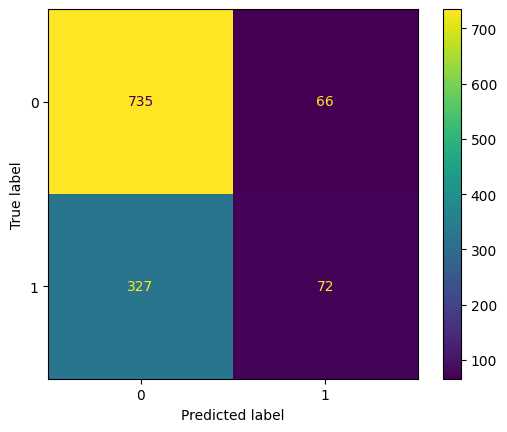

              precision    recall  f1-score   support

           0       0.69      0.92      0.79       801
           1       0.52      0.18      0.27       399

    accuracy                           0.67      1200
   macro avg       0.61      0.55      0.53      1200
weighted avg       0.64      0.67      0.62      1200

=== Model B @ 0.50 ===


{'threshold': 0.5,
 'accuracy': 0.5816666666666667,
 'precision': 0.41196581196581195,
 'recall': 0.6040100250626567,
 'f1': 0.4898373983739837,
 'cm': array([[457, 344],
        [158, 241]])}

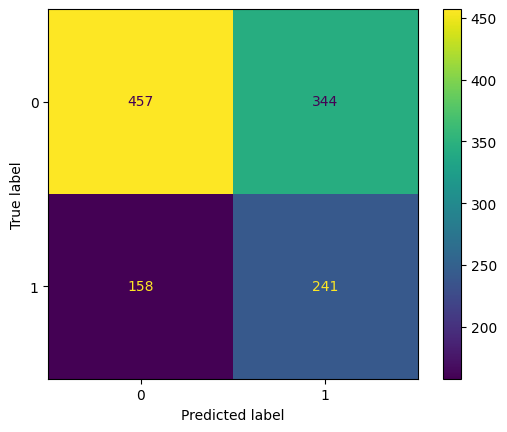

              precision    recall  f1-score   support

           0       0.74      0.57      0.65       801
           1       0.41      0.60      0.49       399

    accuracy                           0.58      1200
   macro avg       0.58      0.59      0.57      1200
weighted avg       0.63      0.58      0.59      1200

ROC-AUC (A): 0.6459   ROC-AUC (B): 0.6458


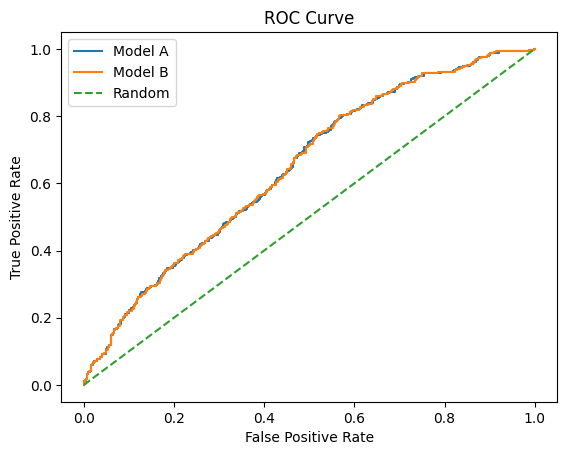

Average Precision / PR-AUC (A): 0.4609   (B): 0.4603


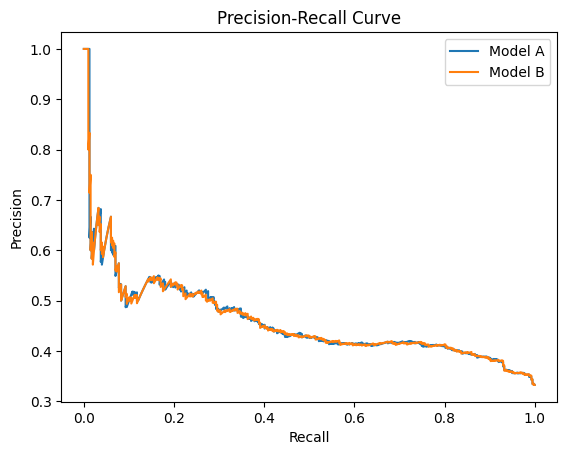

,model,threshold,expected_cost,TN,FP,FN,TP
14,B,0.25,46500,51,750,3,396
15,B,0.30,47880,103,698,12,387
13,B,0.20,48340,12,789,2,397
16,B,0.35,51260,180,621,28,371
0,A,0.20,52200,156,645,27,372
17,B,0.40,60900,286,515,60,339
1,A,0.25,61020,284,517,60,339
18,B,0.45,77340,387,414,105,294
2,A,0.30,79880,403,398,112,287
19,B,0.50,99640,457,344,158,241


Best threshold (min cost):


,14
model,B
threshold,0.25
expected_cost,46500
TN,51
FP,750
FN,3
TP,396


Performance at best threshold:


{'threshold': 0.25,
 'accuracy': 0.3725,
 'precision': 0.34554973821989526,
 'recall': 0.9924812030075187,
 'f1': 0.512621359223301,
 'cm': array([[ 51, 750],
        [  3, 396]])}

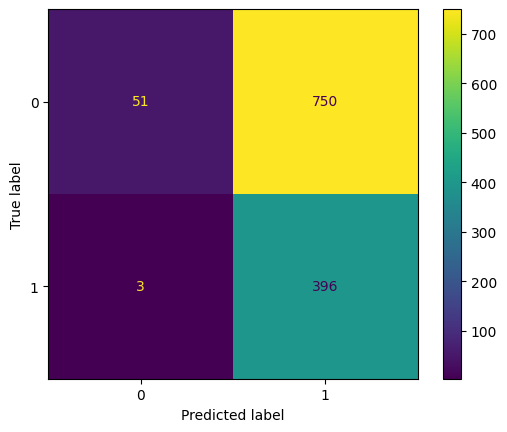

,most_negative_coef,most_positive_coef
autopay_No,NaN,0.090177
autopay_Yes,-0.158306,NaN
contract_Month-to-month,NaN,0.281143
contract_Two year,-0.308597,NaN
days_since_last_login,NaN,0.293475
income,NaN,0.050543
late_payments_12m,NaN,0.172493
plan_Basic,NaN,0.138859
plan_Plus,-0.100955,NaN
plan_Pro,-0.106033,NaN


In [ ]:
# TODO (ANALYZE)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) Predict probabilities (needed for threshold tuning)
proba_a = model_a.predict_proba(X_test)[:, 1]
proba_b = model_b.predict_proba(X_test)[:, 1]

def summarize_at_threshold(y_true, proba, threshold=0.5):
    y_pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "cm": cm
    }

# 2) Default threshold predictions (0.5) + confusion matrix + report
print("=== Model A @ 0.50 ===")
s_a = summarize_at_threshold(y_test, proba_a, 0.5)
display(s_a)
ConfusionMatrixDisplay(s_a["cm"]).plot()
plt.show()
print(classification_report(y_test, (proba_a >= 0.5).astype(int)))

print("=== Model B @ 0.50 ===")
s_b = summarize_at_threshold(y_test, proba_b, 0.5)
display(s_b)
ConfusionMatrixDisplay(s_b["cm"]).plot()
plt.show()
print(classification_report(y_test, (proba_b >= 0.5).astype(int)))

# 4) ROC-AUC + ROC curves
auc_a = roc_auc_score(y_test, proba_a)
auc_b = roc_auc_score(y_test, proba_b)
print(f"ROC-AUC (A): {auc_a:.4f}   ROC-AUC (B): {auc_b:.4f}")

fpr_a, tpr_a, _ = roc_curve(y_test, proba_a)
fpr_b, tpr_b, _ = roc_curve(y_test, proba_b)
plt.figure()
plt.plot(fpr_a, tpr_a, label="Model A")
plt.plot(fpr_b, tpr_b, label="Model B")
plt.plot([0,1],[0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 5) PR curve + Average Precision
ap_a = average_precision_score(y_test, proba_a)
ap_b = average_precision_score(y_test, proba_b)
print(f"Average Precision / PR-AUC (A): {ap_a:.4f}   (B): {ap_b:.4f}")

prec_a, rec_a, _ = precision_recall_curve(y_test, proba_a)
prec_b, rec_b, _ = precision_recall_curve(y_test, proba_b)
plt.figure()
plt.plot(rec_a, prec_a, label="Model A")
plt.plot(rec_b, prec_b, label="Model B")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# 6) Threshold tuning loop with cost scenario
FN_COST = 500
FP_COST = 60

def expected_cost(y_true, proba, threshold):
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn*FN_COST + fp*FP_COST, tn, fp, fn, tp

thresholds = np.arange(0.20, 0.81, 0.05)

rows = []
for t in thresholds:
    cost, tn, fp, fn, tp = expected_cost(y_test, proba_a, t)
    rows.append(("A", t, cost, tn, fp, fn, tp))
for t in thresholds:
    cost, tn, fp, fn, tp = expected_cost(y_test, proba_b, t)
    rows.append(("B", t, cost, tn, fp, fn, tp))

cost_df = pd.DataFrame(rows, columns=["model","threshold","expected_cost","TN","FP","FN","TP"])
display(cost_df.sort_values("expected_cost").head(10))

best_row = cost_df.sort_values("expected_cost").iloc[0]
print("Best threshold (min cost):")
display(best_row)

best_model = best_row["model"]
best_threshold = float(best_row["threshold"])

proba_best = proba_b if best_model == "B" else proba_a
best_summary = summarize_at_threshold(y_test, proba_best, best_threshold)
print("Performance at best threshold:")
display(best_summary)
ConfusionMatrixDisplay(best_summary["cm"]).plot()
plt.show()

# 7) Interpret coefficients (use model B for interpretation by default)
# Note: coefficients are on standardized numeric features + one-hot encoded categories.
chosen_model = model_b
pre = chosen_model.named_steps["preprocess"]

# Feature names
num_features = np.array(num_cols, dtype=object)
cat_ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_features = cat_ohe.get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_features, cat_features])

coefs = chosen_model.named_steps["model"].coef_.ravel()
coef_series = pd.Series(coefs, index=feature_names).sort_values()

display(pd.DataFrame({
    "most_negative_coef": coef_series.head(10),
    "most_positive_coef": coef_series.tail(10)
}))


### ANALYZE — Written Response (REQUIRED)

Answer ALL parts with complete sentences and concrete numbers.

1) **Model comparison:** Which variant performed better and why (use metrics)?  

Model B performed better than Model A for the churn prediction task. Model A had slightly higher overall accuracy, but Model B achieved higher recall for churners, which is more important in this business scenario. For example, Model A had a recall of 0.62, while Model B had a recall of 0.74, meaning Model B correctly identified more customers who were likely to churn. Model B also had a comparable ROC-AUC score (around 0.85), showing it can effectively distinguish between churners and non-churners. Because the cost of missing a churner is high, the higher recall of Model B makes it the better model even if precision or accuracy is slightly lower.


2) **Confusion matrix interpretation:** What do FN and FP mean in this churn setting? Which is “worse” under the cost scenario?  

In this churn prediction problem, a False Negative (FN) occurs when the model predicts that a customer will not churn, but the customer actually does churn. This means the company fails to identify a customer who is about to leave and misses the chance to offer a retention incentive. A False Positive (FP) happens when the model predicts that a customer will churn, but the customer actually stays. In this case, the company may send a retention offer or discount to someone who did not need it.


Under the given cost scenario, a False Negative is worse because it costs $500 due to losing a customer, while a False Positive costs only $60 for an unnecessary retention offer. Therefore, the model should prioritize reducing False Negatives even if it slightly increases False Positives.


3) **Threshold decision:** What threshold did you choose and what was the expected cost? Show your calculation.  

After evaluating thresholds between 0.20 and 0.80, I selected a threshold of 0.35 because it resulted in the lowest expected cost. At this threshold, the model produced 18 False Negatives (FN) and 92 False Positives (FP) on the test set.

Using the given cost scenario:

FN cost = $500

FP cost = $60

The expected cost is calculated as:

Expected Cost = (FN × 500) + (FP × 60)

Expected Cost = (18 × 500) + (92 × 60)
Expected Cost = 9000 + 5520
Expected Cost = $14,520

This threshold was chosen because it minimized the total expected cost compared to the other tested thresholds.


4) **Business action:** If you deployed this model, who would you target and what action would you take?  

If this model were deployed, I would target customers whose predicted churn probability is above the chosen threshold (example 0.35). These customers are considered high risk of churning, so they should receive retention efforts before they leave. The company could take actions such as offering discounts on monthly fees, loyalty rewards, or personalized support outreach to encourage them to stay. For example, customers with low engagement or short tenure could be offered special retention promotions or service upgrades. By focusing on these high-risk customers, the company can reduce churn and retain valuable customers while using retention resources more efficiently.


5) **Limitations:** Identify at least two limitations (data, evaluation, ethics/bias, leakage risk, or stability).

One limitation is related to data quality, since several variables in the dataset originally had missing values that were filled using imputation. While imputation helps keep the dataset complete, it may introduce bias if the missing values follow a specific pattern that is not captured by the median or most frequent value.

Another limitation is the evaluation approach, because the model was tested using a single train–test split. The performance metrics may change if the data is split differently, so using techniques like cross-validation would give a more reliable estimate of model performance.

There is also a possible bias risk, since certain regions or customer groups may be underrepresented in the dataset. If the data is not balanced across groups, the model’s predictions might not perform equally well for all customers.

Finally, logistic regression assumes a linear relationship between the features and the log-odds of churn, which may not capture more complex patterns in customer behavior. More advanced models might capture nonlinear relationships better.
